In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")


EXCEL_PATH = "Raw Data_Predictive Analysis.xlsx"      
DATE_COL   = "OrderDate"                
QTY_COL    = "total_qty_sales"            
RESAMPLE_RULE = "M"                # D=daily, W=weekly, M=monthly (change if needed)


# Load
df = pd.read_excel(EXCEL_PATH)

# Quick peek
print(df.head())
print(df.dtypes)
print("Missing values:\n", df.isna().sum())


   OrderDate  ParentProductIdNew ParentProductNew ProductCategoryNew  \
0 2019-01-01                  11       Product 11         Category 1   
1 2019-01-01                 114      Product 114         Category 8   
2 2019-01-01                  98       Product 98         Category 8   
3 2019-01-01                  97       Product 97         Category 8   
4 2019-01-01                   8        Product 8         Category 1   

  ArtistNameNew  total_qty_sales  Selling Price  productListViews  \
0         TSSOS                3          399.0               NaN   
1          TSSA               10          549.0               NaN   
2         TSSHT                8          499.0               NaN   
3          TSSF                6          549.0               NaN   
4         TSSML                6          399.0               NaN   

   productListClicks  
0                NaN  
1                NaN  
2                NaN  
3                NaN  
4                NaN  
OrderDate     

In [7]:
# Convert date
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')
df = df.dropna(subset=[DATE_COL, QTY_COL])  # drop rows where date/qty missing

# Sort & keep useful cols
df = df[[DATE_COL, QTY_COL]].sort_values(DATE_COL).reset_index(drop=True)

# If quantity should be numeric
df[QTY_COL] = pd.to_numeric(df[QTY_COL], errors='coerce').fillna(0)


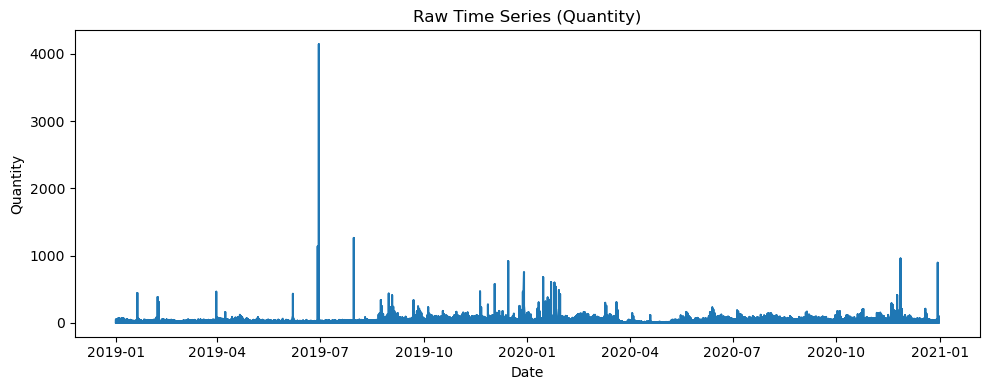

In [9]:
#plotting 
plt.figure(figsize=(10,4))
plt.plot(df[DATE_COL], df[QTY_COL])
plt.title("Raw Time Series (Quantity)")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.tight_layout()
plt.show()


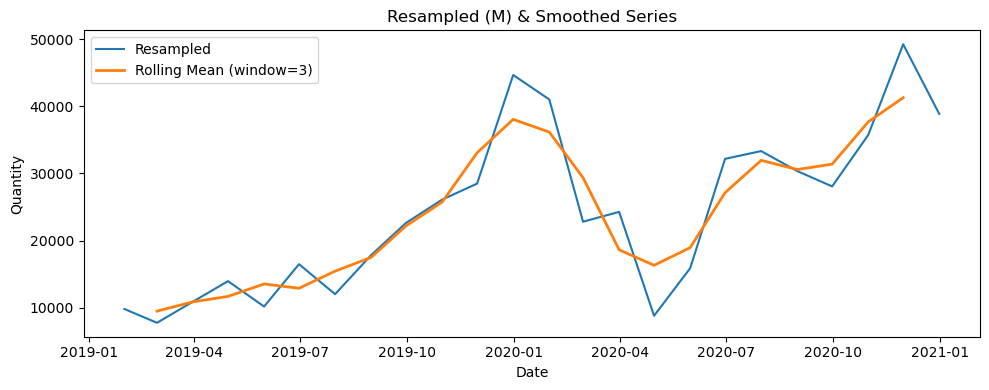

In [11]:
#Resample & smooth
# Set index as date
ts = df.set_index(DATE_COL)

# Resample: sum per period (sales/production quantities commonly summed)
y = ts[QTY_COL].resample(RESAMPLE_RULE).sum()

# Fill missing periods with 0 (change to .ffill() if zero is not appropriate)
y = y.fillna(0)

# Rolling smoothing (window based on frequency)
window_map = {"D":7, "W":4, "M":3}
roll_window = window_map.get(RESAMPLE_RULE, 3)
y_smooth = y.rolling(roll_window, center=True).mean()

plt.figure(figsize=(10,4))
plt.plot(y, label="Resampled")
plt.plot(y_smooth, label=f"Rolling Mean (window={roll_window})", linewidth=2)
plt.title(f"Resampled ({RESAMPLE_RULE}) & Smoothed Series")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()
plt.tight_layout()
plt.show()


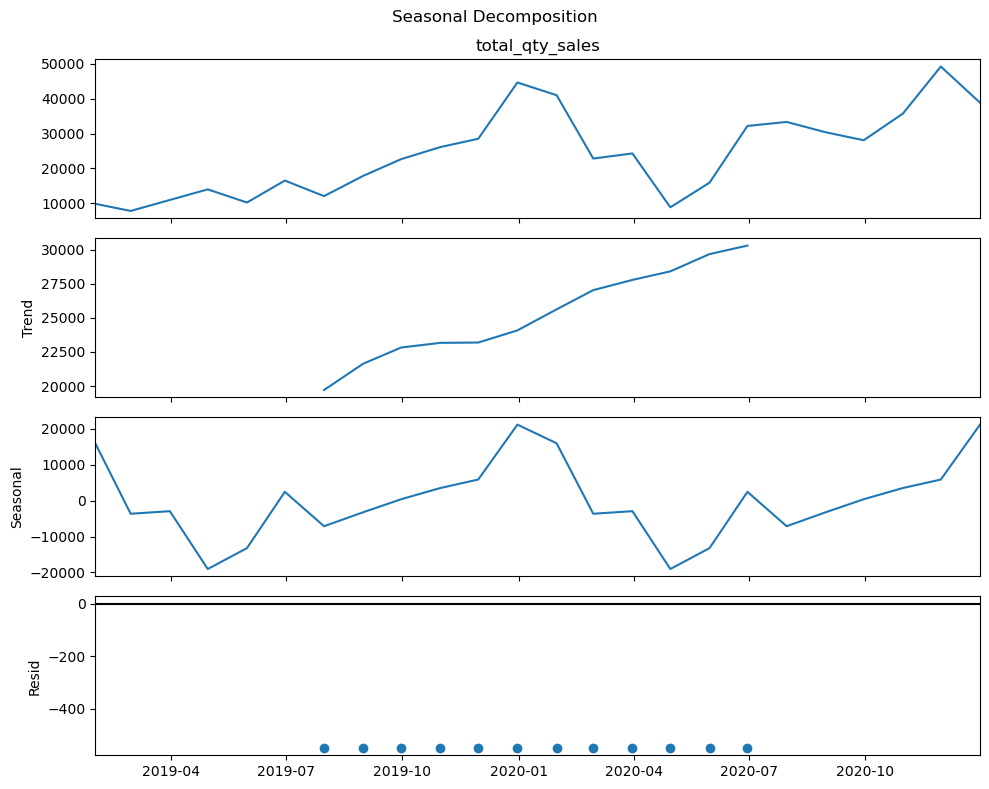

In [13]:
#Decomposition (Trend/Seasonality/Residual)
# Period choose based on frequency
period_map = {"D":7, "W":52, "M":12}
period = period_map.get(RESAMPLE_RULE, 12)

decomp = seasonal_decompose(y, model='additive', period=period)

fig = decomp.plot()
fig.set_size_inches(10, 8)
plt.suptitle("Seasonal Decomposition", y=0.98)
plt.tight_layout()
plt.show()


Train periods: 19 | Test periods: 5


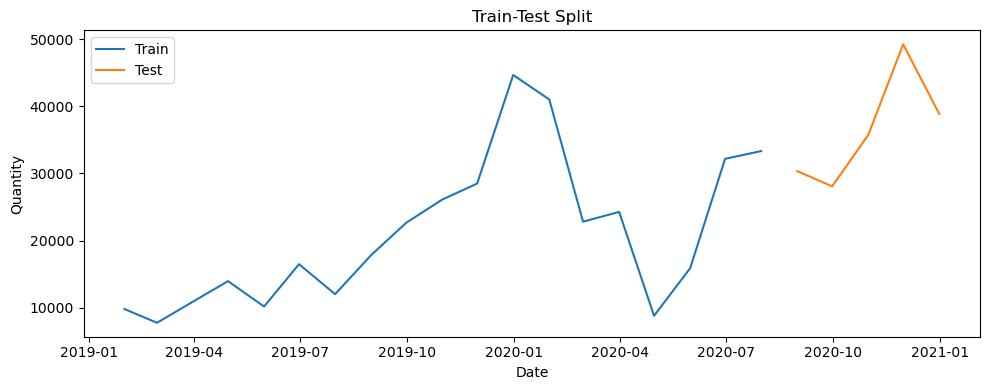

In [33]:
# 80/20 split by time
split_idx = int(len(y) * 0.8)
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train periods:", len(y_train), "| Test periods:", len(y_test))

plt.figure(figsize=(10,4))
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Test")
plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
#
import itertools

p = d = q = [0,1,2]  # small grid
best_aic = np.inf
best_order = None
best_model = None

for order in itertools.product(p, d, q):
    try:
        model = ARIMA(y_train, order=order).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_order = order
            best_model = model
    except Exception:
        continue

print("Best ARIMA order (p,d,q):", best_order, "| AIC:", round(best_aic, 2))


Best ARIMA order (p,d,q): None | AIC: inf


In [51]:
#Forecast
# Refit best model on full train
model = ARIMA(y_train, order=best_order).fit()

# Forecast horizon = len(test)
n_forecast = len(y_test)
forecast_res = model.get_forecast(steps=n_forecast)
y_pred = forecast_res.predicted_mean
y_pred_ci = forecast_res.conf_int()  # confidence intervals

# Align index to test dates
y_pred.index = y_test.index
y_pred_ci.index = y_test.index


TypeError: 'NoneType' object is not subscriptable

In [53]:
#Evaluation (MSE/RMSE) + Visualization
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MSE: {mse:.2f} | RMSE: {rmse:.2f}")

plt.figure(figsize=(10,5))
plt.plot(y_train, label="Train")
plt.plot(y_test, label="Actual (Test)")
plt.plot(y_pred, label="Forecast", linewidth=2)
plt.fill_between(y_pred_ci.index, y_pred_ci.iloc[:,0], y_pred_ci.iloc[:,1],
                 alpha=0.2, label="95% CI")
plt.title(f"ARIMA Forecast vs Actual | RMSE={rmse:.2f}")
plt.xlabel("Date")
plt.ylabel("Quantity")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'y_pred' is not defined

KeyError: 'OrderDate'

0